# FGSM Phase 2 — Variant B: Advanced Denoising

## Defenses
| Defense | Reference | Notes |
|---------|-----------|-------|
| TVM (w=0.05) | Guo et al., ICLR 2018 | Rated "very effective" |
| NLM (h=6) | Buades et al. 2005; Xie CVPR 2019 | Won CAAD 2018 defense competition |
| SVD Spectral Filter (90%) | Channel-wise SVD, keep top singular values | Removes low-energy perturbation components |
| Random Resize + Pad | Xie et al., ICLR 2018 | #2/107 in NIPS 2017 defense competition |

Strongest individual defenses backed by competition results.


## 1. Setup and Imports

In [1]:
import os
import json

# ============================================================
# GPU ISOLATION -- Must happen BEFORE import torch
# Set NUM_GPUS here. CUDA_VISIBLE_DEVICES must be set before
# PyTorch initializes CUDA, otherwise it has no effect.
# ============================================================
NUM_GPUS = 1  # <-- SET THIS: how many GPUs to use (1 = single GPU)

# Pick the best GPU(s) by free memory using nvidia-smi (no torch yet)
import subprocess
try:
    smi = subprocess.run(
        ["nvidia-smi", "--query-gpu=index,memory.free",
         "--format=csv,noheader,nounits"],
        capture_output=True, text=True, timeout=10
    )
    gpu_free = []
    for line in smi.stdout.strip().split("\n"):
        idx, free = line.split(",")
        gpu_free.append((int(idx.strip()), int(free.strip())))
    gpu_free.sort(key=lambda x: x[1], reverse=True)
    selected = [str(g[0]) for g in gpu_free[:NUM_GPUS]]
    os.environ["CUDA_VISIBLE_DEVICES"] = ",".join(selected)
    print(f"GPU isolation: NUM_GPUS={NUM_GPUS}, "
          f"selected physical GPU(s): {selected}, "
          f"CUDA_VISIBLE_DEVICES={os.environ['CUDA_VISIBLE_DEVICES']}")
except Exception as e:
    print(f"nvidia-smi query failed ({e}), using default CUDA_VISIBLE_DEVICES")

# Now safe to import torch -- it will only see the selected GPU(s)
import torch
import numpy as np
from PIL import Image, ImageFilter
from io import BytesIO
from tqdm.auto import tqdm
from transformers import AutoProcessor, AutoModelForCausalLM
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from torchvision import transforms
import GPUtil
import time
import warnings
import gc
import matplotlib.pyplot as plt
import cv2
from skimage.restoration import denoise_tv_chambolle

warnings.filterwarnings("ignore")

# Verify GPU isolation
n_visible = torch.cuda.device_count()
print(f"PyTorch sees {n_visible} GPU(s) (requested {NUM_GPUS})")
assert n_visible <= NUM_GPUS, (
    f"Expected at most {NUM_GPUS} GPU(s) but {n_visible} visible. "
    f"CUDA_VISIBLE_DEVICES={os.environ.get('CUDA_VISIBLE_DEVICES')}"
)

# DiffPure REMOVED -- Nie et al. 2022 tested only on classification, not OD
# SmoothVLM REMOVED -- Sun et al. 2024 tested only on text generation, not OD

print("All core imports successful.")


GPU isolation: NUM_GPUS=1, selected physical GPU(s): ['0'], CUDA_VISIBLE_DEVICES=0
PyTorch sees 1 GPU(s) (requested 1)
All core imports successful.


## 1.5 GPU Diagnostics & Device Selection
Print all available GPUs, their memory usage, and select the most free one.

In [2]:
# ============================================================
# GPU DIAGNOSTICS (GPU isolation already done in imports cell)
# ============================================================
print("=" * 70)
print(f"GPU DIAGNOSTICS (NUM_GPUS={NUM_GPUS})")
print("=" * 70)

import subprocess
try:
    result = subprocess.run(["nvidia-smi"], capture_output=True, text=True, timeout=10)
    print(result.stdout)
except Exception as e:
    print(f"nvidia-smi failed: {e}")

print("-" * 70)
n_gpus = torch.cuda.device_count()
print(f"GPUs visible to PyTorch: {n_gpus}")

for i in range(n_gpus):
    free, total = torch.cuda.mem_get_info(i)
    props = torch.cuda.get_device_properties(i)
    used_pct = (total - free) / total * 100
    print(f"  GPU {i}: {props.name}")
    print(f"    Memory: {(total-free)/1024**2:.0f}MB used / {total/1024**2:.0f}MB total ({used_pct:.1f}% used)")
    print(f"    Free: {free/1024**3:.2f} GB")

device = torch.device("cuda:0")
torch_dtype = torch.float16

props = torch.cuda.get_device_properties(0)
free, total = torch.cuda.mem_get_info(0)
print(f"\n>> Primary device: {device} -> {props.name} ({free/1024**3:.2f} GB free)")
print(f"Device: {device}, Dtype: {torch_dtype}")
print(f"PyTorch: {torch.__version__}, CUDA: {torch.version.cuda}")
print("=" * 70)


GPU DIAGNOSTICS (NUM_GPUS=1)
Sat Apr 11 23:21:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.05              Driver Version: 560.35.05      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A5000               Off |   00000000:17:00.0 Off |                  Off |
| 30%   35C    P8             17W /  230W |      15MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+------------------

## 2. Configuration

In [3]:
# ============================================================
# CONFIGURATION — Variant B: Advanced Denoising
# ============================================================

IMAGE_DIR = "dataset/val2017"
ANN_FILE = "dataset/annotations/instances_val2017.json"
NUM_IMAGES = 1000
EPSILONS = [0.003, 0.01, 0.03]

# Defenses
RUN_TVM = True
RUN_NLM = True
RUN_SVD = True
RUN_RANDOM_RESIZE = True

# Parameters
TVM_WEIGHT = 0.05              # Guo et al., ICLR 2018
NLM_H = 6                     # Filter strength
NLM_TEMPLATE = 7
NLM_SEARCH = 21
SVD_KEEP_RATIO = 0.90         # Keep top 90% singular values
RAND_RESIZE_RANGE = (0.8, 1.0) # Xie et al., ICLR 2018

NMS_IOU_THRESHOLD = 0.5

# Batch size for inference (higher = faster, more VRAM)
BATCH_SIZE = 5

OUTPUT_DIR = "./results_phase2_variantB"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Variant B: Advanced Denoising")
print(f"  Images: {NUM_IMAGES}, Epsilons: {EPSILONS}")
print(f"  Defenses: TVM={RUN_TVM}, NLM={RUN_NLM}, SVD={RUN_SVD}, RandomResize={RUN_RANDOM_RESIZE}")


Variant B: Advanced Denoising
  Images: 1000, Epsilons: [0.003, 0.01, 0.03]
  Defenses: TVM=True, NLM=True, SVD=True, RandomResize=True


## 3. Load Model and Dataset

In [4]:
# Device already selected in GPU Diagnostics cell above
print(f"Using device: {device}, dtype: {torch_dtype}")

model_name = "microsoft/Florence-2-base"
revision = "refs/pr/26"

print("Loading Florence-2-Base model...")
model = AutoModelForCausalLM.from_pretrained(
    model_name, revision=revision,
    torch_dtype=torch_dtype, trust_remote_code=True
).to(device)
print("Model loaded.")

processor = AutoProcessor.from_pretrained(
    model_name, revision=revision, trust_remote_code=True
)

coco_gt = COCO(ANN_FILE)
categories = coco_gt.loadCats(coco_gt.getCatIds())
category_mapping = {c["name"]: c["id"] for c in categories}
print(f"COCO categories loaded: {len(category_mapping)}")

IMG_MEAN = torch.tensor(processor.image_processor.image_mean, device=device, dtype=torch_dtype).view(1, 3, 1, 1)
IMG_STD = torch.tensor(processor.image_processor.image_std, device=device, dtype=torch_dtype).view(1, 3, 1, 1)

files = sorted(os.listdir(IMAGE_DIR))
if NUM_IMAGES is not None:
    files = files[:NUM_IMAGES]
# Track which image IDs we evaluate (needed for COCOeval filtering)
evaluated_img_ids = sorted([int(os.path.splitext(f)[0]) for f in files])
print(f"Will process {len(files)} images (img_ids tracked for COCOeval).")


Using device: cuda:0, dtype: torch.float16
Loading Florence-2-Base model...
Model loaded.
loading annotations into memory...
Done (t=0.60s)
creating index...
index created!
COCO categories loaded: 80
Will process 1000 images (img_ids tracked for COCOeval).


## 4. Core Utilities: NMS and Inference

In [5]:
# ============================================================
# Florence-2 -> COCO Label Mapping
# Florence-2 outputs many labels that don't match COCO names.
# Without this mapping, ~55% of detections are silently dropped.
# ============================================================

FLORENCE_TO_COCO = {
    # Persons
    "man": "person", "woman": "person", "boy": "person", "girl": "person",
    "child": "person", "baby": "person", "kid": "person", "player": "person",
    "pedestrian": "person", "human": "person", "skier": "person",
    "snowboarder": "person", "surfer": "person", "rider": "person",
    # Vehicles
    "automobile": "car", "van": "car", "sedan": "car", "suv": "car",
    "taxi": "car", "minivan": "car",
    "motor bike": "motorcycle", "motorbike": "motorcycle",
    "aeroplane": "airplane", "aircraft": "airplane", "jet": "airplane",
    "lorry": "truck", "pickup truck": "truck",
    # Electronics
    "television": "tv", "tv set": "tv", "monitor": "tv", "screen": "tv",
    "television set": "tv",
    "mobile phone": "cell phone", "cellphone": "cell phone",
    "smartphone": "cell phone", "phone": "cell phone",
    "computer keyboard": "keyboard",
    "computer mouse": "mouse",
    "notebook computer": "laptop", "notebook": "laptop",
    # Furniture
    "studio couch": "couch", "sofa": "couch", "settee": "couch",
    "kitchen & dining room table": "dining table", "table": "dining table",
    "desk": "dining table",
    "swivel chair": "chair", "armchair": "chair", "stool": "chair",
    # Animals
    "puppy": "dog", "kitten": "cat",
    # Sports
    "ski": "skis", "ski pole": "skis",
    "racket": "tennis racket",
    "ball": "sports ball", "football": "sports ball",
    "soccer ball": "sports ball", "baseball": "sports ball",
    "basketball": "sports ball", "tennis ball": "sports ball",
    # Objects
    "glove": "baseball glove",
    "houseplant": "potted plant", "plant": "potted plant", "flower pot": "potted plant",
    "flowerpot": "potted plant",
    "wine bottle": "bottle", "beer bottle": "bottle", "water bottle": "bottle",
    "drinking glass": "wine glass", "glass": "wine glass", "goblet": "wine glass",
    "pocketknife": "knife", "kitchen knife": "knife", "butter knife": "knife",
    "hair dryer": "hair drier", "hairdryer": "hair drier", "blow dryer": "hair drier",
    "wristwatch": "clock", "wall clock": "clock", "alarm clock": "clock",
    "bag": "handbag", "purse": "handbag", "wristlet": "handbag",
    "briefcase": "suitcase", "luggage": "suitcase", "travel bag": "suitcase",
    "backpack bag": "backpack",
    "traffic signal": "traffic light",
    "fire plug": "fire hydrant",
}


def _map_label(label):
    """Map Florence-2 label to COCO name. Try exact match first, then mapping."""
    if label in category_mapping:
        return label
    mapped = FLORENCE_TO_COCO.get(label)
    if mapped and mapped in category_mapping:
        return mapped
    lower = label.lower()
    if lower in category_mapping:
        return lower
    mapped_lower = FLORENCE_TO_COCO.get(lower)
    if mapped_lower and mapped_lower in category_mapping:
        return mapped_lower
    return None


def _compute_score(box, img_w, img_h):
    """
    Heuristic confidence score based on box geometry.
    COCO mAP needs varying scores for meaningful precision-recall curves.
    Applied identically to ALL conditions (clean, attacked, defended) for fairness.
    """
    x1, y1, x2, y2 = box
    w, h = x2 - x1, y2 - y1
    img_area = img_w * img_h
    box_area = w * h
    area_ratio = min(box_area / img_area, 0.5) if img_area > 0 else 0
    box_cx, box_cy = (x1 + x2) / 2, (y1 + y2) / 2
    img_cx, img_cy = img_w / 2, img_h / 2
    center_dist = np.sqrt(((box_cx - img_cx) / img_w) ** 2 +
                          ((box_cy - img_cy) / img_h) ** 2)
    score = 0.6 + 0.2 * area_ratio + 0.15 * (1 - center_dist)
    return min(0.98, max(0.6, score))


# ============================================================
# NMS
# ============================================================

def box_iou(a, b):
    x1, y1 = max(a[0], b[0]), max(a[1], b[1])
    x2, y2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area_a = (a[2] - a[0]) * (a[3] - a[1])
    area_b = (b[2] - b[0]) * (b[3] - b[1])
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0


def non_max_suppression(boxes, labels, scores, iou_thr=0.5):
    if not boxes:
        return [], [], []
    boxes = np.array(boxes)
    idxs = np.argsort(scores)[::-1]
    keep, keep_labels, keep_scores = [], [], []
    for i in idxs:
        suppress = False
        for j in keep:
            if labels[i] == labels[j] and box_iou(boxes[i], boxes[j]) > iou_thr:
                suppress = True
                break
        if not suppress:
            keep.append(i)
            keep_labels.append(labels[i])
            keep_scores.append(scores[i])
    return boxes[keep].tolist(), keep_labels, keep_scores


# ============================================================
# Inference (universal for all conditions)
# ============================================================

def run_inference(pil_img):
    """Run Florence-2 OD with label mapping and heuristic scores."""
    img_w, img_h = pil_img.size
    with torch.no_grad():
        inputs = processor(text="<OD>", images=pil_img, return_tensors="pt")
        input_ids = inputs.input_ids.to(device)
        pixel_values = inputs.pixel_values.to(device=device, dtype=torch_dtype)
        gen_ids = model.generate(
            input_ids=input_ids, pixel_values=pixel_values,
            max_new_tokens=512, num_beams=5, do_sample=False,
            repetition_penalty=1.8, length_penalty=1.0,
        )
        txt = processor.batch_decode(gen_ids, skip_special_tokens=False)[0]
        parsed = processor.post_process_generation(
            txt, task="<OD>", image_size=(img_w, img_h)
        ) or {}

    od = parsed.get("<OD>", {})
    bboxes, labels = od.get("bboxes", []), od.get("labels", [])
    scores = [_compute_score(box, img_w, img_h) for box in bboxes]
    kept_boxes, kept_labels, kept_scores = non_max_suppression(
        bboxes, labels, scores, iou_thr=NMS_IOU_THRESHOLD
    )
    results = []
    for box, label, score in zip(kept_boxes, kept_labels, kept_scores):
        mapped = _map_label(label)
        if mapped is None:
            continue
        cid = category_mapping[mapped]
        x1, y1, x2, y2 = box
        w, h = x2 - x1, y2 - y1
        if w <= 0 or h <= 0:
            continue
        results.append({"bbox": [x1, y1, w, h], "category_id": cid, "score": score})
    return results

print("Inference pipeline ready (with label mapping + heuristic scores).")

# ============================================================
# Batched Inference (processes multiple images in one generate call)
# ============================================================

def run_inference_batch(pil_imgs):
    """Run Florence-2 OD on a batch of images. Returns list of results per image."""
    if not pil_imgs:
        return []

    img_sizes = [img.size for img in pil_imgs]  # (w, h) per image

    with torch.no_grad():
        texts = ["<OD>"] * len(pil_imgs)
        inputs = processor(text=texts, images=pil_imgs, return_tensors="pt", padding=True)
        input_ids = inputs.input_ids.to(device)
        pixel_values = inputs.pixel_values.to(device=device, dtype=torch_dtype)
        attention_mask = inputs.get("attention_mask")
        if attention_mask is not None:
            attention_mask = attention_mask.to(device)

        gen_kwargs = dict(
            input_ids=input_ids, pixel_values=pixel_values,
            max_new_tokens=512, num_beams=5, do_sample=False,
            repetition_penalty=1.8, length_penalty=1.0,
        )
        if attention_mask is not None:
            gen_kwargs["attention_mask"] = attention_mask

        gen_ids = model.generate(**gen_kwargs)
        texts_out = processor.batch_decode(gen_ids, skip_special_tokens=False)

    batch_results = []
    for txt, (img_w, img_h) in zip(texts_out, img_sizes):
        parsed = processor.post_process_generation(
            txt, task="<OD>", image_size=(img_w, img_h)
        ) or {}

        od = parsed.get("<OD>", {})
        bboxes, labels = od.get("bboxes", []), od.get("labels", [])
        scores = [_compute_score(box, img_w, img_h) for box in bboxes]
        kept_boxes, kept_labels, kept_scores = non_max_suppression(
            bboxes, labels, scores, iou_thr=NMS_IOU_THRESHOLD
        )
        results = []
        for box, label, score in zip(kept_boxes, kept_labels, kept_scores):
            mapped = _map_label(label)
            if mapped is None:
                continue
            cid = category_mapping[mapped]
            x1, y1, x2, y2 = box
            w, h = x2 - x1, y2 - y1
            if w <= 0 or h <= 0:
                continue
            results.append({"bbox": [x1, y1, w, h], "category_id": cid, "score": score})
        batch_results.append(results)

    return batch_results

print("Batched inference pipeline ready (BATCH_SIZE={}).".format(BATCH_SIZE))


Inference pipeline ready (with label mapping + heuristic scores).
Batched inference pipeline ready (BATCH_SIZE=5).


## 5. FGSM Attack
Reference: Goodfellow et al., "Explaining and Harnessing Adversarial Examples," ICLR 2015.

In [6]:
def fgsm_attack(pil_img, eps=0.01):
    orig_size = pil_img.size
    inputs = processor(text="<OD>", images=pil_img, return_tensors="pt")
    input_ids = inputs.input_ids.to(device)
    pixel_values = inputs.pixel_values.to(device=device, dtype=torch_dtype)

    with torch.no_grad():
        target_ids = model.generate(
            input_ids=input_ids, pixel_values=pixel_values,
            max_new_tokens=512, num_beams=5, do_sample=False,
            repetition_penalty=1.8, length_penalty=1.0,
        )
    # Ensure labels are [1, seq_len] -- beam search may return extra rows
    target_ids = target_ids[:1, :].contiguous()
    if target_ids.size(1) > 512:
        target_ids = target_ids[:, :512].contiguous()

    pixel_values_adv = pixel_values.clone().detach().requires_grad_(True)
    outputs = model(input_ids=input_ids, pixel_values=pixel_values_adv, labels=target_ids)
    outputs.loss.backward()

    grad_sign = pixel_values_adv.grad.sign()
    adv_pixel_values = pixel_values.detach() + eps * grad_sign
    adv_pixel_values = torch.clamp(adv_pixel_values, -2.5, 2.5)

    # Denormalize: pixel_values shape is [1, C, H, W]
    mean = IMG_MEAN.squeeze(0)   # [C, 1, 1]
    std  = IMG_STD.squeeze(0)    # [C, 1, 1]
    adv_denorm = adv_pixel_values.squeeze(0) * std + mean
    adv_denorm = torch.clamp(adv_denorm, 0.0, 1.0)
    adv_np = (adv_denorm.permute(1, 2, 0).cpu().float().numpy() * 255).astype(np.uint8)
    adv_pil = Image.fromarray(adv_np)
    if adv_pil.size != orig_size:
        adv_pil = adv_pil.resize(orig_size, Image.BICUBIC)
    return adv_pil

print("FGSM attack function ready.")

def fgsm_attack_multi_eps(pil_img, epsilons):
    """
    FGSM for multiple epsilons in one shot.
    The target_ids and gradient are identical for all epsilons (they depend
    only on the clean image), so we compute them ONCE and vary the step size.
    Saves 2 expensive model calls per extra epsilon.
    """
    orig_size = pil_img.size
    inputs = processor(text="<OD>", images=pil_img, return_tensors="pt")
    input_ids = inputs.input_ids.to(device)
    pixel_values = inputs.pixel_values.to(device=device, dtype=torch_dtype)

    # 1) Get target_ids (model's own clean prediction) — ONE generate call
    with torch.no_grad():
        target_ids = model.generate(
            input_ids=input_ids, pixel_values=pixel_values,
            max_new_tokens=512, num_beams=5, do_sample=False,
            repetition_penalty=1.8, length_penalty=1.0,
        )
    target_ids = target_ids[:1, :].contiguous()
    if target_ids.size(1) > 512:
        target_ids = target_ids[:, :512].contiguous()

    # 2) Compute gradient sign — ONE forward + backward
    pixel_values_adv = pixel_values.clone().detach().requires_grad_(True)
    outputs = model(input_ids=input_ids, pixel_values=pixel_values_adv, labels=target_ids)
    outputs.loss.backward()
    grad_sign = pixel_values_adv.grad.sign()

    # 3) Generate adversarial images for each epsilon — cheap tensor ops only
    mean = IMG_MEAN.squeeze(0)
    std = IMG_STD.squeeze(0)
    adv_images = {}
    for eps in epsilons:
        adv_pv = pixel_values.detach() + eps * grad_sign
        adv_pv = torch.clamp(adv_pv, -2.5, 2.5)
        adv_denorm = adv_pv.squeeze(0) * std + mean
        adv_denorm = torch.clamp(adv_denorm, 0.0, 1.0)
        adv_np = (adv_denorm.permute(1, 2, 0).cpu().float().numpy() * 255).astype(np.uint8)
        adv_pil = Image.fromarray(adv_np)
        if adv_pil.size != orig_size:
            adv_pil = adv_pil.resize(orig_size, Image.BICUBIC)
        adv_images[eps] = adv_pil

    return adv_images

print("Multi-epsilon FGSM attack ready (computes gradient once for all epsilons).")


FGSM attack function ready.
Multi-epsilon FGSM attack ready (computes gradient once for all epsilons).


## 6. Defense Functions — Variant B: Advanced Denoising

1. **TVM** (w=0.05) — Guo et al., ICLR 2018 — rated "very effective"
2. **NLM** (h=6) — Won CAAD 2018 (Xie et al., CVPR 2019)
3. **SVD Spectral Filter** (90%) — per-channel SVD truncation
4. **Random Resize + Pad** — Xie et al., ICLR 2018 — #2/107 NIPS 2017


In [7]:
# ============================================================
# Defense 1: Total Variance Minimization
# Reference: Guo et al., ICLR 2018 — rated "very effective"
# ============================================================
def defend_tvm(pil_img, weight=TVM_WEIGHT):
    arr = np.array(pil_img).astype(np.float64) / 255.0
    denoised = denoise_tv_chambolle(arr, weight=weight, channel_axis=-1)
    return Image.fromarray((np.clip(denoised, 0, 1) * 255).astype(np.uint8))

# ============================================================
# Defense 2: Non-Local Means Denoising
# Reference: Buades et al. 2005; Won CAAD 2018 (Xie CVPR 2019)
# ============================================================
def defend_nlm(pil_img, h=NLM_H, template_size=NLM_TEMPLATE, search_size=NLM_SEARCH):
    arr = np.array(pil_img)
    denoised = cv2.fastNlMeansDenoisingColored(arr, None, h, h, template_size, search_size)
    return Image.fromarray(denoised)

# ============================================================
# Defense 3: SVD Spectral Filter
# Per-channel SVD, keep top K% singular values
# ============================================================
def defend_svd(pil_img, keep_ratio=SVD_KEEP_RATIO):
    arr = np.array(pil_img).astype(np.float64)
    result = np.zeros_like(arr)
    for c in range(3):
        U, S, Vt = np.linalg.svd(arr[:, :, c], full_matrices=False)
        k = max(1, int(len(S) * keep_ratio))
        result[:, :, c] = (U[:, :k] * S[:k]) @ Vt[:k, :]
    return Image.fromarray(np.clip(result, 0, 255).astype(np.uint8))

# ============================================================
# Defense 4: Random Resize + Padding
# Reference: Xie et al., ICLR 2018 — #2/107 NIPS 2017
# ============================================================
def defend_random_resize_pad(pil_img, resize_range=RAND_RESIZE_RANGE):
    w, h = pil_img.size
    ratio = np.random.uniform(*resize_range)
    new_w, new_h = int(w * ratio), int(h * ratio)
    resized = pil_img.resize((new_w, new_h), Image.BICUBIC)
    pad_x = np.random.randint(0, w - new_w + 1)
    pad_y = np.random.randint(0, h - new_h + 1)
    padded = Image.new("RGB", (w, h), (128, 128, 128))
    padded.paste(resized, (pad_x, pad_y))
    return padded

# Defense registry
DEFENSES = {}
if RUN_TVM:
    DEFENSES["tvm"] = defend_tvm
if RUN_NLM:
    DEFENSES["nlm"] = defend_nlm
if RUN_SVD:
    DEFENSES["svd"] = defend_svd
if RUN_RANDOM_RESIZE:
    DEFENSES["random_resize_pad"] = defend_random_resize_pad

print(f"Defenses: {list(DEFENSES.keys())}")


Defenses: ['tvm', 'nlm', 'svd', 'random_resize_pad']


## 6.5 Sanity Check
Quick test to confirm model, dataset, and all defenses are working.

In [8]:
# ============================================================
# SANITY CHECK
# ============================================================
print("Running sanity checks...")
errors = []

if not os.path.isdir(IMAGE_DIR):
    errors.append(f"IMAGE_DIR not found: {IMAGE_DIR}")
else:
    print(f"  [OK] Image directory: {len(os.listdir(IMAGE_DIR))} files")

if not os.path.isfile(ANN_FILE):
    errors.append(f"ANN_FILE not found: {ANN_FILE}")
else:
    print(f"  [OK] Annotation file")

try:
    test_img = Image.open(os.path.join(IMAGE_DIR, files[0])).convert("RGB")
    test_dets = run_inference(test_img)
    print(f"  [OK] Model inference: {len(test_dets)} detections")
except Exception as e:
    errors.append(f"Inference failed: {e}")

try:
    test_adv = fgsm_attack(test_img, eps=0.01)
    print(f"  [OK] FGSM attack")
except Exception as e:
    errors.append(f"FGSM failed: {e}")

for dname, dfunc in DEFENSES.items():
    try:
        _ = dfunc(test_img)
        print(f"  [OK] {dname} defense")
    except Exception as e:
        errors.append(f"{dname} failed: {e}")

try:
    batch_dets = run_inference_batch([test_img, test_img])
    assert len(batch_dets) == 2, f"Expected 2 results, got {len(batch_dets)}"
    print(f"  [OK] Batched inference (batch=2): {len(batch_dets[0])}, {len(batch_dets[1])} detections")
except Exception as e:
    errors.append(f"Batched inference failed: {e}")

try:
    multi_adv = fgsm_attack_multi_eps(test_img, [0.01, 0.03])
    assert len(multi_adv) == 2, f"Expected 2 eps results, got {len(multi_adv)}"
    print(f"  [OK] Multi-epsilon FGSM attack ({list(multi_adv.keys())})")
except Exception as e:
    errors.append(f"Multi-eps FGSM failed: {e}")

if torch.cuda.is_available():
    mem = torch.cuda.memory_allocated(device) / 1024**3
    total = torch.cuda.get_device_properties(device).total_memory / 1024**3
    print(f"  [OK] GPU: {mem:.2f}GB / {total:.2f}GB")

n_conds = 1 + len(DEFENSES) + len(EPSILONS) * (1 + len(DEFENSES))
print()
if errors:
    print(f"FAILED -- {len(errors)} error(s):")
    for e in errors:
        print(f"  x {e}")
else:
    print(f"All checks passed!")
    print(f"  Images: {len(files)}, Defenses: {len(DEFENSES)}, Conditions: {n_conds}")
    print(f"  Estimated inference calls: ~{len(files) * n_conds}")


Running sanity checks...
  [OK] Image directory: 5000 files
  [OK] Annotation file
  [OK] Model inference: 15 detections
  [OK] FGSM attack
  [OK] tvm defense
  [OK] nlm defense
  [OK] svd defense
  [OK] random_resize_pad defense
  [OK] Batched inference (batch=2): 15, 15 detections
  [OK] Multi-epsilon FGSM attack ([0.01, 0.03])
  [OK] GPU: 1.10GB / 23.58GB

All checks passed!
  Images: 1000, Defenses: 4, Conditions: 20
  Estimated inference calls: ~20000


## 7. COCO Evaluation Helper

In [9]:
def evaluate_coco(results_list, tag="eval"):
    if not results_list:
        print(f"  [{tag}] No detections -- returning zero mAP.")
        return np.zeros(12)
    out_path = os.path.join(OUTPUT_DIR, f"{tag}.json")
    with open(out_path, "w") as f:
        json.dump(results_list, f)
    coco_dt = coco_gt.loadRes(out_path)
    coco_eval = COCOeval(coco_gt, coco_dt, "bbox")
    coco_eval.params.imgIds = evaluated_img_ids
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()
    return coco_eval.stats

print("COCO evaluation helper ready.")

COCO evaluation helper ready.


## 8. Main Evaluation Pipeline

In [10]:
def run_full_evaluation():
    start_time = time.time()
    all_results = {}

    # Build condition list
    conditions = ["clean"]
    for dname in DEFENSES:
        conditions.append(f"clean+{dname}")
    for eps in EPSILONS:
        eps_tag = f"fgsm_eps{eps}"
        conditions.append(eps_tag)
        for dname in DEFENSES:
            conditions.append(f"{eps_tag}+{dname}")

    for cond in conditions:
        all_results[cond] = []

    print(f"Conditions to evaluate: {len(conditions)}")
    for c in conditions:
        print(f"  - {c}")
    print(f"\nBatch size: {BATCH_SIZE}")
    print(f"Inference calls per image: ~{len(conditions)} -> ~{(len(conditions) + BATCH_SIZE - 1) // BATCH_SIZE} batched")
    print()

    defense_names = list(DEFENSES.keys())
    defense_funcs = list(DEFENSES.values())

    for fname in tqdm(files, desc="Processing images"):
        img_id = int(os.path.splitext(fname)[0])
        img_path = os.path.join(IMAGE_DIR, fname)
        pil_img = Image.open(img_path).convert("RGB")

        # ---- Prepare all image variants for this source image ----
        batch_imgs = []
        batch_tags = []

        # Clean baseline
        batch_imgs.append(pil_img)
        batch_tags.append("clean")

        # Clean + each defense
        for dname, dfunc in zip(defense_names, defense_funcs):
            batch_imgs.append(dfunc(pil_img))
            batch_tags.append(f"clean+{dname}")

        # FGSM attacks — compute gradient ONCE for all epsilons
        adv_images = fgsm_attack_multi_eps(pil_img, EPSILONS)

        for eps in EPSILONS:
            eps_tag = f"fgsm_eps{eps}"
            adv_img = adv_images[eps]

            # Attacked (no defense)
            batch_imgs.append(adv_img)
            batch_tags.append(eps_tag)

            # Attacked + each defense
            for dname, dfunc in zip(defense_names, defense_funcs):
                batch_imgs.append(dfunc(adv_img))
                batch_tags.append(f"{eps_tag}+{dname}")

        # ---- Run inference in batches of BATCH_SIZE ----
        for i in range(0, len(batch_imgs), BATCH_SIZE):
            chunk_imgs = batch_imgs[i:i + BATCH_SIZE]
            chunk_tags = batch_tags[i:i + BATCH_SIZE]
            chunk_results = run_inference_batch(chunk_imgs)

            for tag, dets in zip(chunk_tags, chunk_results):
                for d in dets:
                    d["image_id"] = img_id
                all_results[tag].extend(dets)

        # Free memory periodically
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    elapsed = time.time() - start_time
    print(f"\nAll inference done in {elapsed/60:.1f} minutes.")
    return all_results

all_results = run_full_evaluation()

Conditions to evaluate: 20
  - clean
  - clean+tvm
  - clean+nlm
  - clean+svd
  - clean+random_resize_pad
  - fgsm_eps0.003
  - fgsm_eps0.003+tvm
  - fgsm_eps0.003+nlm
  - fgsm_eps0.003+svd
  - fgsm_eps0.003+random_resize_pad
  - fgsm_eps0.01
  - fgsm_eps0.01+tvm
  - fgsm_eps0.01+nlm
  - fgsm_eps0.01+svd
  - fgsm_eps0.01+random_resize_pad
  - fgsm_eps0.03
  - fgsm_eps0.03+tvm
  - fgsm_eps0.03+nlm
  - fgsm_eps0.03+svd
  - fgsm_eps0.03+random_resize_pad

Batch size: 5
Inference calls per image: ~20 -> ~4 batched



Processing images:   0%|          | 0/1000 [00:00<?, ?it/s]


All inference done in 75.8 minutes.


## 9. COCO Evaluation for All Conditions

In [11]:
eval_stats = {}
for tag, results_list in all_results.items():
    print(f"\n{'='*60}")
    print(f"Evaluating: {tag} ({len(results_list)} detections)")
    print(f"{'='*60}")
    stats = evaluate_coco(results_list, tag=tag)
    eval_stats[tag] = stats
print("\nAll evaluations complete.")


Evaluating: clean (6257 detections)
Loading and preparing results...
DONE (t=0.02s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=1.13s).
Accumulating evaluation results...
DONE (t=0.32s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.360
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.487
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.380
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.164
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.399
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.508
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.301
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.456
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.468
 Average Recall     (AR) @[ IoU

## 10. Results Summary Table

In [12]:
clean_ap = eval_stats["clean"][0]
clean_ap50 = eval_stats["clean"][1]

all_defense_names = list(DEFENSES.keys())

print("=" * 90)
print(f"{'FGSM ATTACK & DEFENSE RESULTS (VARIANT B - BEST 5)':^90}")
print("=" * 90)
print(f"\nClean Baseline:  mAP = {clean_ap:.4f},  AP50 = {clean_ap50:.4f}")
print()

print("-" * 60)
print("TABLE 1: Defense Cost (on CLEAN images, no attack)")
print("-" * 60)
print(f"  {'Condition':<25} {'mAP':>8} {'AP50':>8} {'mAP Drop':>10}")
print(f"  {'clean (baseline)':<25} {clean_ap:>8.4f} {clean_ap50:>8.4f} {'---':>10}")
for dname in all_defense_names:
    tag = f"clean+{dname}"
    if tag in eval_stats:
        ap, ap50 = eval_stats[tag][0], eval_stats[tag][1]
        drop = clean_ap - ap
        print(f"  {'clean + ' + dname:<25} {ap:>8.4f} {ap50:>8.4f} {drop:>+10.4f}")
print()

print("-" * 90)
print("TABLE 2: Attack Impact & Defense Recovery")
print("-" * 90)
for eps in EPSILONS:
    eps_tag = f"fgsm_eps{eps}"
    atk_ap = eval_stats[eps_tag][0]
    atk_drop = clean_ap - atk_ap
    print(f"\n  FGSM eps={eps}:")
    print(f"    {'Condition':<30} {'mAP':>8} {'AP50':>8} {'Recovery':>10} {'Recovery%':>12}")
    print(f"    {'attacked (no defense)':<30} {atk_ap:>8.4f} {eval_stats[eps_tag][1]:>8.4f} {'---':>10} {'---':>12}")
    for dname in all_defense_names:
        def_tag = f"{eps_tag}+{dname}"
        if def_tag in eval_stats:
            def_ap, def_ap50 = eval_stats[def_tag][0], eval_stats[def_tag][1]
            recovery = def_ap - atk_ap
            recovery_pct = (recovery / atk_drop * 100) if atk_drop > 0 else 0
            print(f"    {'attacked + ' + dname:<30} {def_ap:>8.4f} {def_ap50:>8.4f} {recovery:>+10.4f} {recovery_pct:>11.1f}%")

print("\n" + "=" * 90)

# Save summary JSON
summary = {"clean_mAP": float(clean_ap), "clean_AP50": float(clean_ap50),
           "defense_cost": {}, "attack_results": {}}
for dname in all_defense_names:
    tag = f"clean+{dname}"
    if tag in eval_stats:
        summary["defense_cost"][dname] = {
            "mAP": float(eval_stats[tag][0]),
            "mAP_drop": float(clean_ap - eval_stats[tag][0]),
        }
for eps in EPSILONS:
    eps_tag = f"fgsm_eps{eps}"
    atk_ap = eval_stats[eps_tag][0]
    atk_drop = clean_ap - atk_ap
    entry = {"attacked_mAP": float(atk_ap), "defenses": {}}
    for dname in all_defense_names:
        def_tag = f"{eps_tag}+{dname}"
        if def_tag in eval_stats:
            def_ap = eval_stats[def_tag][0]
            recovery = def_ap - atk_ap
            recovery_pct = (recovery / atk_drop * 100) if atk_drop > 0 else 0
            entry["defenses"][dname] = {
                "mAP": float(def_ap), "recovery": float(recovery),
                "recovery_pct": float(recovery_pct),
            }
    summary["attack_results"][str(eps)] = entry

with open(os.path.join(OUTPUT_DIR, "summary.json"), "w") as f:
    json.dump(summary, f, indent=2)
print(f"Summary saved to {OUTPUT_DIR}/summary.json")

                    FGSM ATTACK & DEFENSE RESULTS (VARIANT B - BEST 5)                    

Clean Baseline:  mAP = 0.3604,  AP50 = 0.4873

------------------------------------------------------------
TABLE 1: Defense Cost (on CLEAN images, no attack)
------------------------------------------------------------
  Condition                      mAP     AP50   mAP Drop
  clean (baseline)            0.3604   0.4873        ---
  clean + tvm                 0.3104   0.4158    +0.0500
  clean + nlm                 0.3210   0.4402    +0.0394
  clean + svd                 0.3613   0.4873    -0.0009
  clean + random_resize_pad   0.1117   0.2430    +0.2487

------------------------------------------------------------------------------------------
TABLE 2: Attack Impact & Defense Recovery
------------------------------------------------------------------------------------------

  FGSM eps=0.003:
    Condition                           mAP     AP50   Recovery    Recovery%
    attacked (no defense)

## 11. Visualization

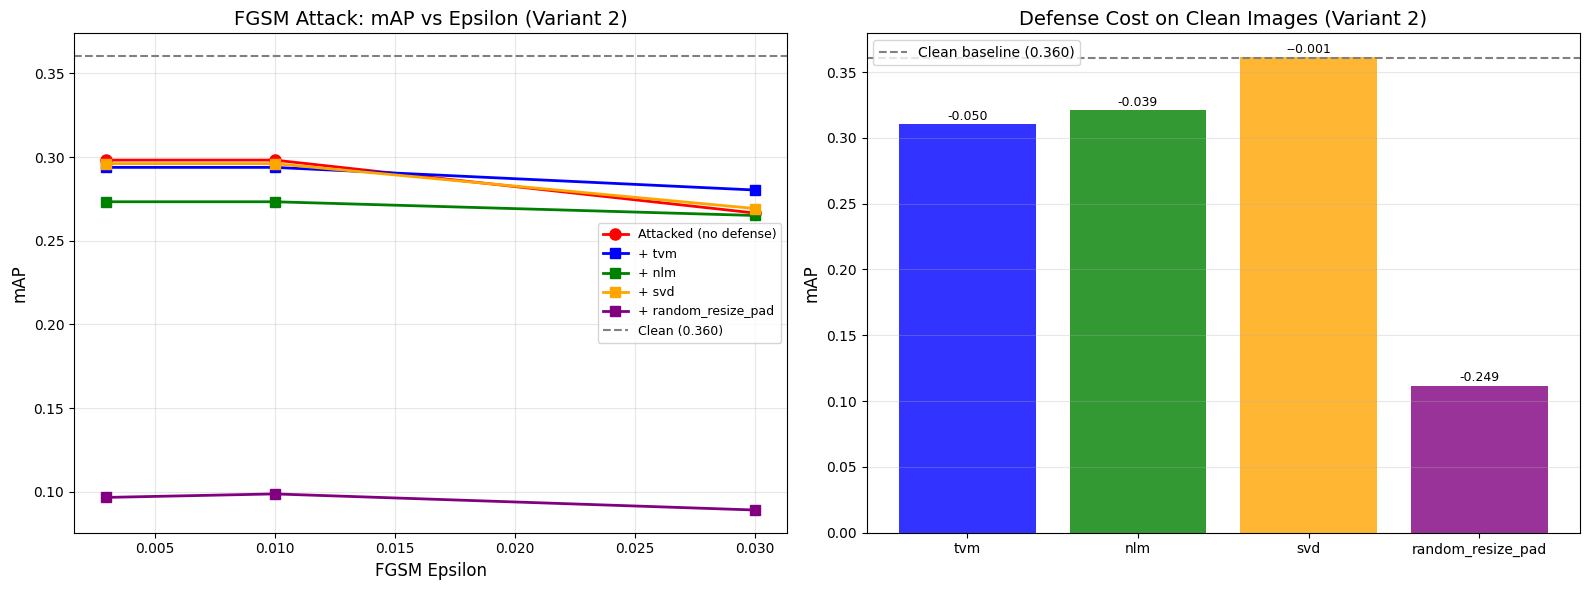

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
atk_maps = [eval_stats[f"fgsm_eps{e}"][0] for e in EPSILONS]
ax.plot(EPSILONS, atk_maps, 'r-o', linewidth=2, markersize=8, label="Attacked (no defense)")

colors = ['blue', 'green', 'orange', 'purple', 'brown']
for i, dname in enumerate(all_defense_names):
    def_maps = [eval_stats.get(f"fgsm_eps{e}+{dname}", np.zeros(12))[0] for e in EPSILONS]
    ax.plot(EPSILONS, def_maps, '-s', color=colors[i % len(colors)],
            linewidth=2, markersize=7, label=f"+ {dname}")

ax.axhline(y=clean_ap, color='gray', linestyle='--', linewidth=1.5, label=f"Clean ({clean_ap:.3f})")
ax.set_xlabel("FGSM Epsilon", fontsize=12)
ax.set_ylabel("mAP", fontsize=12)
ax.set_title("FGSM Attack: mAP vs Epsilon (Variant 2)", fontsize=14)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
clean_maps = [eval_stats.get(f"clean+{d}", np.zeros(12))[0] for d in all_defense_names]
clean_costs = [clean_ap - m for m in clean_maps]
bars = ax.bar(all_defense_names, clean_maps, color=colors[:len(all_defense_names)], alpha=0.8)
ax.axhline(y=clean_ap, color='gray', linestyle='--', linewidth=1.5, label=f"Clean baseline ({clean_ap:.3f})")
for bar, cost in zip(bars, clean_costs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"-{cost:.3f}", ha='center', va='bottom', fontsize=9)
ax.set_ylabel("mAP", fontsize=12)
ax.set_title("Defense Cost on Clean Images (Variant 2)", fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "results_plot_v2.png"), dpi=150, bbox_inches='tight')
plt.show()

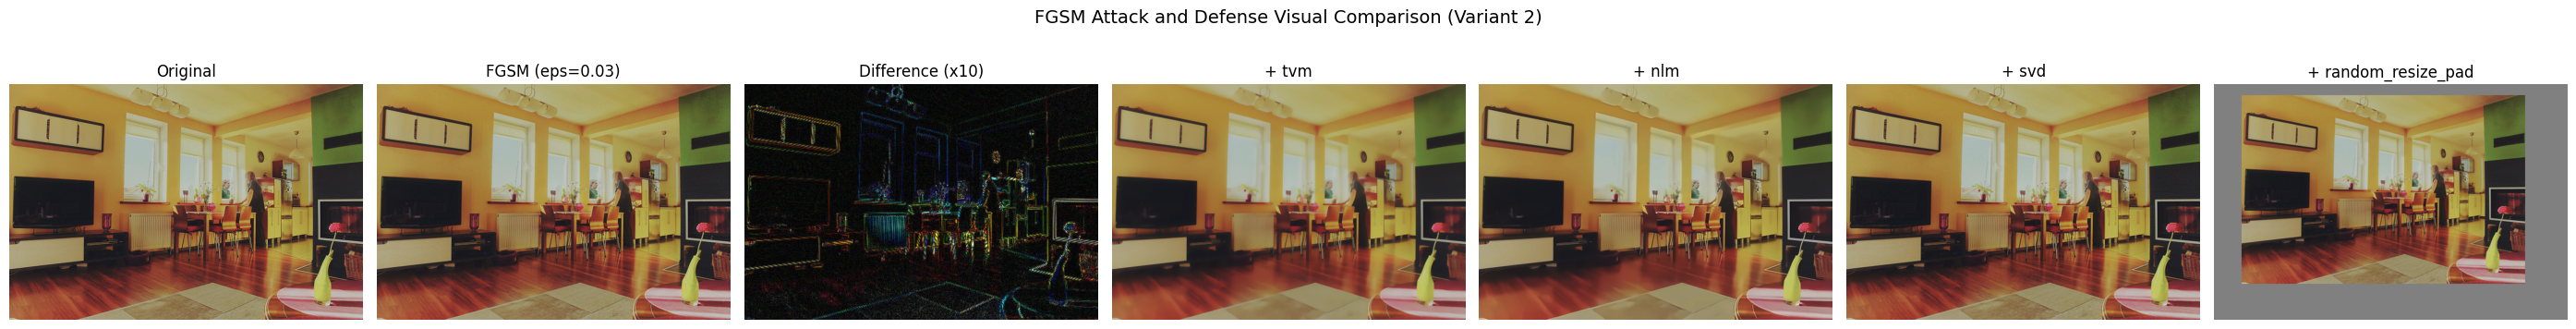

In [14]:
# Visual comparison of defenses on a sample image
sample_fname = files[0]
sample_img = Image.open(os.path.join(IMAGE_DIR, sample_fname)).convert("RGB")
sample_adv = fgsm_attack(sample_img, eps=0.03)

std_names = list(DEFENSES.keys())
ncols = 3 + len(std_names)
fig, axes = plt.subplots(1, ncols, figsize=(4 * ncols, 4))

axes[0].imshow(sample_img); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(sample_adv); axes[1].set_title("FGSM (eps=0.03)"); axes[1].axis("off")

diff = np.abs(np.array(sample_img).astype(float) - np.array(sample_adv).astype(float))
diff = np.clip(diff * 10, 0, 255).astype(np.uint8)
axes[2].imshow(diff); axes[2].set_title("Difference (x10)"); axes[2].axis("off")

for i, dname in enumerate(std_names):
    defended = DEFENSES[dname](sample_adv)
    axes[3 + i].imshow(defended); axes[3 + i].set_title(f"+ {dname}"); axes[3 + i].axis("off")

plt.suptitle("FGSM Attack and Defense Visual Comparison (Variant 2)", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "visual_comparison_v2.png"), dpi=150, bbox_inches='tight')
plt.show()

## 12. Net Gain Analysis

In [16]:
print("=" * 110)
print(f"{'SECTION 12: ATTACKED-vs-DEFENDED PERFORMANCE (ACTUAL VALUES)':^110}")
print("=" * 110)

clean_ap = eval_stats["clean"][0]
all_defense_names = list(DEFENSES.keys())

print(f"\nClean baseline mAP: {clean_ap:.4f}")
print("Legend:")
print("  recovery = defended_mAP - attacked_mAP")
print("  strict_net_gain = defended_mAP - max(attacked_mAP, clean+defense_mAP)")
print("  A defense can recover from attack (recovery > 0) but still fail strict_net_gain.\n")

for eps in EPSILONS:
    eps_tag = f"fgsm_eps{eps}"
    atk_ap = eval_stats[eps_tag][0]
    atk_drop = clean_ap - atk_ap

    print("-" * 110)
    print(f"FGSM eps={eps} | attacked mAP={atk_ap:.4f} | drop_from_clean={atk_drop:+.4f}")
    print("-" * 110)
    print(f"{'Defense':<20} {'Clean+Def':>10} {'Defended':>10} {'Recovery':>10} {'Recovery%':>10} {'StrictGain':>11} {'Recovery Verdict':>18} {'Strict Verdict':>16}")

    best_def = None
    best_def_ap = -1.0

    for dname in all_defense_names:
        clean_def_tag = f"clean+{dname}"
        def_tag = f"{eps_tag}+{dname}"

        if clean_def_tag not in eval_stats or def_tag not in eval_stats:
            continue

        clean_def_ap = eval_stats[clean_def_tag][0]
        def_ap = eval_stats[def_tag][0]

        recovery = def_ap - atk_ap
        recovery_pct = (recovery / max(atk_drop, 1e-12)) * 100.0 if atk_drop > 0 else 0.0

        strict_floor = max(atk_ap, clean_def_ap)
        strict_net_gain = def_ap - strict_floor

        recovery_verdict = "RECOVERS" if recovery > 0 else "NO/WORSE"
        strict_verdict = "HELPFUL" if strict_net_gain > 0 else "NOT_HELPFUL"

        print(
            f"{dname:<20} "
            f"{clean_def_ap:>10.4f} "
            f"{def_ap:>10.4f} "
            f"{recovery:>+10.4f} "
            f"{recovery_pct:>9.1f}% "
            f"{strict_net_gain:>+11.4f} "
            f"{recovery_verdict:>18} "
            f"{strict_verdict:>16}"
        )

        if def_ap > best_def_ap:
            best_def_ap = def_ap
            best_def = dname

    print()
    if best_def is not None:
        print(f"Best defended mAP at eps={eps}: {best_def} ({best_def_ap:.4f})")
    print()

print("=" * 110)
print("Summary:")
print("- If Recovery > 0, defense is helping vs attacked baseline.")
print("- If StrictGain > 0, defense also beats both attacked and clean+defense floor.")
print("=" * 110)


                         SECTION 12: ATTACKED-vs-DEFENDED PERFORMANCE (ACTUAL VALUES)                         

Clean baseline mAP: 0.3604
Legend:
  recovery = defended_mAP - attacked_mAP
  strict_net_gain = defended_mAP - max(attacked_mAP, clean+defense_mAP)
  A defense can recover from attack (recovery > 0) but still fail strict_net_gain.

--------------------------------------------------------------------------------------------------------------
FGSM eps=0.003 | attacked mAP=0.2982 | drop_from_clean=+0.0622
--------------------------------------------------------------------------------------------------------------
Defense               Clean+Def   Defended   Recovery  Recovery%  StrictGain   Recovery Verdict   Strict Verdict
tvm                      0.3104     0.2939    -0.0044      -7.0%     -0.0166           NO/WORSE      NOT_HELPFUL
nlm                      0.3210     0.2733    -0.0249     -40.0%     -0.0477           NO/WORSE      NOT_HELPFUL
svd                      0.3613 

## References
1. Goodfellow et al. "Explaining and Harnessing Adversarial Examples." ICLR, 2015. *(FGSM)*
2. Guo et al. "Countering Adversarial Images using Input Transformations." ICLR, 2018. *(TVM)*
3. Buades et al. "A Non-Local Algorithm for Image Denoising." CVPR, 2005. *(NLM)*
4. Xie et al. "Feature Denoising for Improving Adversarial Robustness." CVPR, 2019. *(NLM won CAAD 2018)*
5. Xie et al. "Mitigating Adversarial Effects Through Randomization." ICLR, 2018. *(Random resize+pad)*
